# ENM 5310 — Aurora precipitation fine-tuning (Head-only, publishable baseline)

Goal: train a small precipitation head on top of **frozen AuroraSmallPretrained**.

This notebook is meant to be the **"results" notebook** (training + eval + plots + saved checkpoints).


## 0) Config (edit only this cell)

In [1]:
from pathlib import Path
from datetime import datetime, timedelta

# Where your existing NetCDFs live (same folder you used)
DATA_DIR = Path("./downloads/era5")

def date_range(start: str, end: str):
    """Inclusive date range as YYYY-MM-DD strings."""
    s = datetime.fromisoformat(start)
    e = datetime.fromisoformat(end)
    out = []
    cur = s
    while cur <= e:
        out.append(cur.strftime("%Y-%m-%d"))
        cur += timedelta(days=1)
    return out

# Deadline-safe split
TRAIN_DATES = date_range("2023-01-01", "2023-01-20")
VAL_DATES   = date_range("2023-01-21", "2023-01-25")

# Training
EPOCHS = 3
LR = 1e-3
BATCH_SIZE = 1   # keep 1 for now (global 720x1440)

# GPU strategy
# If this OOMs, set BACKBONE_ON_GPU=False and we'll run Aurora on CPU and head on GPU.
BACKBONE_ON_GPU = False
HEAD_ON_GPU = True

# Output
OUT_DIR = Path("./runs/aurora_tp_head")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = OUT_DIR / "precip_head.pt"

print("Config loaded.")
print("TRAIN_DATES:", len(TRAIN_DATES))
print("VAL_DATES:", len(VAL_DATES))


Config loaded.
TRAIN_DATES: 20
VAL_DATES: 5


In [ ]:
################################
## Downloading data if needed ##
################################

from pathlib import Path
import cdsapi

c = cdsapi.Client()
out = Path("downloads/era5")
out.mkdir(parents=True, exist_ok=True)

def download_day(date_str):
    y, m, d = date_str.split("-")

    surf = out / f"{date_str}-surface-level.nc"
    atm  = out / f"{date_str}-atmospheric.nc"
    tp   = out / f"{date_str}-tp-hourly-01_to_06.nc"

    if not surf.exists():
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": [
                    "2m_temperature",
                    "10m_u_component_of_wind",
                    "10m_v_component_of_wind",
                    "mean_sea_level_pressure",
                ],
                "year": y, "month": m, "day": d,
                "time": ["00:00", "06:00", "12:00", "18:00"],
                "format": "netcdf",
            },
            str(surf),
        )

    if not atm.exists():
        c.retrieve(
            "reanalysis-era5-pressure-levels",
            {
                "product_type": "reanalysis",
                "variable": [
                    "temperature",
                    "u_component_of_wind",
                    "v_component_of_wind",
                    "specific_humidity",
                    "geopotential",
                ],
                "pressure_level": ["1000","850","500","200"],
                "year": y, "month": m, "day": d,
                "time": ["00:00", "06:00", "12:00", "18:00"],
                "format": "netcdf",
            },
            str(atm),
        )

    if not tp.exists():
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": ["total_precipitation"],
                "year": y, "month": m, "day": d,
                "time": [f"{h:02d}:00" for h in range(1, 7)],
                "format": "netcdf",
            },
            str(tp),
        )

    print("✓", date_str)


for d in TRAIN_DATES + VAL_DATES:
    download_day(d)


## 1) Imports + device

In [3]:
import json
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import xarray as xr

from aurora import Batch, Metadata
from aurora import AuroraSmallPretrained

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


torch: 2.7.1+cu128
cuda available: True
device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2) Load normalization stats (from your baseline)

In [4]:
STATS_PATH = Path("./tp_normalization.json")
assert STATS_PATH.exists(), "Missing tp_normalization.json (run baseline notebook Step 5)."

with open(STATS_PATH, "r") as f:
    stats = json.load(f)

MU = float(stats["mean"])
STD = float(stats["std"])
print("Loaded stats:", stats)
print("MU, STD:", MU, STD)


Loaded stats: {'target': 'log1p_tp_6h', 'mean': 0.0005497062811627984, 'std': 0.0019855170976370573, 'units': 'log(1 + meters)'}
MU, STD: 0.0005497062811627984 0.0019855170976370573


## 3) Helper: build Batch + target for one day

In [5]:
def build_paths(date_str: str):
    """Returns (surf_path, atm_path, tp_path, static_path)."""
    surf = DATA_DIR / f"{date_str}-surface-level.nc"
    atm  = DATA_DIR / f"{date_str}-atmospheric.nc"
    tp   = DATA_DIR / f"{date_str}-tp-hourly-01_to_06.nc"
    static = DATA_DIR / "static.nc"
    return surf, atm, tp, static


def build_batch(date_str: str) -> Batch:
    surf_path, atm_path, _, static_path = build_paths(date_str)
    assert surf_path.exists(), f"Missing {surf_path}"
    assert atm_path.exists(), f"Missing {atm_path}"
    assert static_path.exists(), f"Missing {static_path}"

    static_ds = xr.open_dataset(static_path)
    surf_ds   = xr.open_dataset(surf_path)
    atm_ds    = xr.open_dataset(atm_path)

    # 2 time steps (t0, t1)
    b = Batch(
        surf_vars={
            "2t":  torch.from_numpy(surf_ds["t2m"].values[:2][None]),
            "10u": torch.from_numpy(surf_ds["u10"].values[:2][None]),
            "10v": torch.from_numpy(surf_ds["v10"].values[:2][None]),
            "msl": torch.from_numpy(surf_ds["msl"].values[:2][None]),
        },
        static_vars={
            "z":   torch.from_numpy(static_ds["z"].values[0]),
            "slt": torch.from_numpy(static_ds["slt"].values[0]),
            "lsm": torch.from_numpy(static_ds["lsm"].values[0]),
        },
        atmos_vars={
            "t": torch.from_numpy(atm_ds["t"].values[:2][None]),
            "u": torch.from_numpy(atm_ds["u"].values[:2][None]),
            "v": torch.from_numpy(atm_ds["v"].values[:2][None]),
            "q": torch.from_numpy(atm_ds["q"].values[:2][None]),
            "z": torch.from_numpy(atm_ds["z"].values[:2][None]),
        },
        metadata=Metadata(
            lat=torch.from_numpy(surf_ds.latitude.values),
            lon=torch.from_numpy(surf_ds.longitude.values),
            time=(surf_ds.valid_time.values.astype("datetime64[s]").tolist()[1],),
            atmos_levels=tuple(int(l) for l in atm_ds.pressure_level.values),
        ),
    )

    static_ds.close(); surf_ds.close(); atm_ds.close()
    return b


def build_target(date_str: str) -> torch.Tensor:
    """Returns y_norm with shape [1,1,720,1440] on CPU."""
    _, _, tp_path, _ = build_paths(date_str)
    assert tp_path.exists(), f"Missing {tp_path}"

    tp_ds = xr.open_dataset(tp_path)
    tp = tp_ds["tp"]

    # Sum hours 1..6 (baseline)
    tp6h = tp.sum(dim="valid_time")

    y = torch.from_numpy(tp6h.values.astype("float32"))  # [H,W]
    y_log = torch.log1p(y)
    y_log_bchw = y_log[None, None].contiguous()  # [1,1,H,W]

    y_norm = (y_log_bchw - MU) / STD

    # Safety crop to match Aurora's 720 latitude grid
    y_norm = y_norm[:, :, :720, :].contiguous()

    tp_ds.close()
    return y_norm


## 4) Helper: pack Aurora features

In [6]:
def pack_surf_features(pred_batch: Batch) -> torch.Tensor:
    x2t  = pred_batch.surf_vars["2t"]
    x10u = pred_batch.surf_vars["10u"]
    x10v = pred_batch.surf_vars["10v"]
    xmsl = pred_batch.surf_vars["msl"]

    X = torch.cat([x2t, x10u, x10v, xmsl], dim=1).float()  # [B,4,H,W]

    # Per-channel standardization (per sample)
    mean = X.mean(dim=(2,3), keepdim=True)
    std  = X.std(dim=(2,3), keepdim=True).clamp_min(1e-6)
    X = (X - mean) / std

    return X


## 5) Model: Aurora (frozen) + Precip head (trainable)

In [7]:
class PrecipHead(nn.Module):
    def __init__(self, in_ch=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=1),
        )
    def forward(self, x):
        return self.net(x)


model = AuroraSmallPretrained(use_lora=False)
model.load_checkpoint("microsoft/aurora", "aurora-0.25-small-pretrained.ckpt")
model.eval()

for p in model.parameters():
    p.requires_grad_(False)

head = PrecipHead(in_ch=4)

if BACKBONE_ON_GPU and device.type == "cuda":
    model = model.to("cuda")
else:
    model = model.to("cpu")

if HEAD_ON_GPU and device.type == "cuda":
    head = head.to("cuda")
else:
    head = head.to("cpu")

print("Backbone device:", next(model.parameters()).device)
print("Head device:", next(head.parameters()).device)


Backbone device: cpu
Head device: cuda:0


## 6) Minimal training/eval loops (head-only)

Important rules (so we don't blow VRAM):
- Aurora forward runs under `torch.no_grad()` (backbone is frozen).
- We delete `pred` and `batch_*` every iteration.
- We only keep the head gradients.

Also: `torch.inference_mode()` creates *inference tensors* that can break autograd if you feed them into a trainable head.
So we use `no_grad()` here.


In [8]:
# Loss: make storms matter more than pure MSE-on-normalized (deadline-safe)
loss_fn = nn.SmoothL1Loss(beta=1.0)
opt = optim.Adam(head.parameters(), lr=LR)

def move_batch(b: Batch, dev: torch.device) -> Batch:
    return b.to(str(dev))


def corrcoef_map(a: torch.Tensor, b: torch.Tensor) -> float:
    """Pearson correlation between two [1,1,H,W] tensors."""
    a = a.detach().float().view(-1)
    b = b.detach().float().view(-1)
    a = a - a.mean()
    b = b - b.mean()
    denom = (a.std(unbiased=False) * b.std(unbiased=False)).clamp_min(1e-12)
    return float((a * b).mean() / denom)


@torch.no_grad()
def eval_one(date_str: str):
    model.eval(); head.eval()

    b = build_batch(date_str)
    y = build_target(date_str)  # CPU

    bb_dev = next(model.parameters()).device
    b_dev = move_batch(b, bb_dev)

    pred = model(b_dev)
    X = pack_surf_features(pred)

    h_dev = next(head.parameters()).device
    X = X.to(h_dev)
    y = y.to(h_dev)

    yhat = head(X)
    loss = float(loss_fn(yhat, y).item())

    # correlation (compute on CPU for stability)
    corr = corrcoef_map(yhat.to("cpu"), y.to("cpu"))

    del b, b_dev, pred, X, y, yhat
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return loss, corr


def train_one_epoch(dates):
    model.eval()  # frozen
    head.train()

    losses = []

    for i, date_str in enumerate(dates):
        b = build_batch(date_str)
        y = build_target(date_str)  # CPU

        bb_dev = next(model.parameters()).device
        b_dev = move_batch(b, bb_dev)

        # Aurora forward (no grads)
        with torch.no_grad():
            pred = model(b_dev)
            X = pack_surf_features(pred)

        h_dev = next(head.parameters()).device
        X = X.to(h_dev)
        y = y.to(h_dev)

        opt.zero_grad(set_to_none=True)
        yhat = head(X)
        loss = loss_fn(yhat, y)
        loss.backward()
        opt.step()

        losses.append(float(loss.item()))

        del b, b_dev, pred, X, y, yhat, loss
        if device.type == "cuda":
            torch.cuda.empty_cache()

        if (i % 1) == 0:
            print(f"  train sample {i+1}/{len(dates)} | loss {losses[-1]:.6f} | date {date_str}")

    return float(np.mean(losses)) if len(losses) else float("nan")


## 7) Run training + validation

Adds proper evaluation:
- Val loss
- Val correlation (Pearson corr between predicted/target maps)


In [9]:
print("TRAIN_DATES:", TRAIN_DATES[:3], "...", TRAIN_DATES[-3:])
print("VAL_DATES:", VAL_DATES)

history = {
    "train_loss": [],
    "val_loss": [],
    "val_corr": [],
}

for ep in range(EPOCHS):
    print(f"\n=== Epoch {ep+1}/{EPOCHS} ===")
    train_loss = train_one_epoch(TRAIN_DATES)
    history["train_loss"].append(train_loss)

    if len(VAL_DATES) > 0:
        vals = [eval_one(d) for d in VAL_DATES]
        val_loss = float(np.mean([v[0] for v in vals]))
        val_corr = float(np.mean([v[1] for v in vals]))
    else:
        val_loss = float("nan")
        val_corr = float("nan")

    history["val_loss"].append(val_loss)
    history["val_corr"].append(val_corr)

    print(f"Epoch {ep+1}: train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | val_corr={val_corr:.4f}")

    torch.save(
        {
            "head_state_dict": head.state_dict(),
            "config": {
                "TRAIN_DATES": TRAIN_DATES,
                "VAL_DATES": VAL_DATES,
                "LR": LR,
                "EPOCHS": EPOCHS,
                "BACKBONE_ON_GPU": BACKBONE_ON_GPU,
                "HEAD_ON_GPU": HEAD_ON_GPU,
                "MU": MU,
                "STD": STD,
                "LOSS": "SmoothL1Loss(beta=1.0)",
            },
            "history": history,
        },
        CHECKPOINT_PATH,
    )
    print("Saved:", CHECKPOINT_PATH)

print("\nDone.")
print("history:", history)


TRAIN_DATES: ['2023-01-01', '2023-01-02', '2023-01-03'] ... ['2023-01-18', '2023-01-19', '2023-01-20']
VAL_DATES: ['2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24', '2023-01-25']

=== Epoch 1/3 ===
  train sample 1/20 | loss 0.163121 | date 2023-01-01
  train sample 2/20 | loss 0.159870 | date 2023-01-02
  train sample 3/20 | loss 0.168937 | date 2023-01-03
  train sample 4/20 | loss 0.176908 | date 2023-01-04
  train sample 5/20 | loss 0.183013 | date 2023-01-05
  train sample 6/20 | loss 0.167602 | date 2023-01-06
  train sample 7/20 | loss 0.155005 | date 2023-01-07
  train sample 8/20 | loss 0.139021 | date 2023-01-08
  train sample 9/20 | loss 0.144668 | date 2023-01-09
  train sample 10/20 | loss 0.156702 | date 2023-01-10
  train sample 11/20 | loss 0.154724 | date 2023-01-11
  train sample 12/20 | loss 0.145006 | date 2023-01-12
  train sample 13/20 | loss 0.153251 | date 2023-01-13
  train sample 14/20 | loss 0.149259 | date 2023-01-14
  train sample 15/20 | loss 0.14989

## 8) Quick qualitative plot (one day)
This is what you can screenshot for your report: target vs prediction.

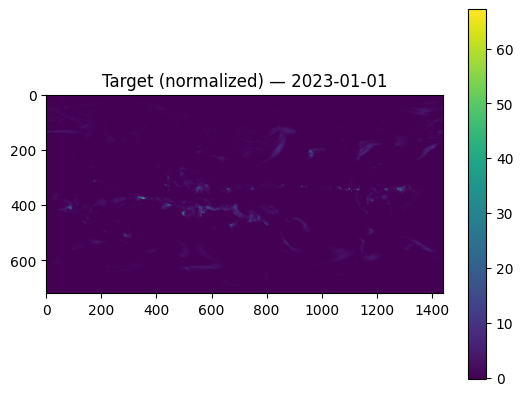

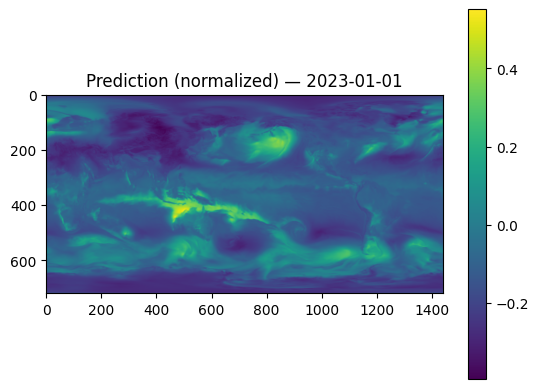

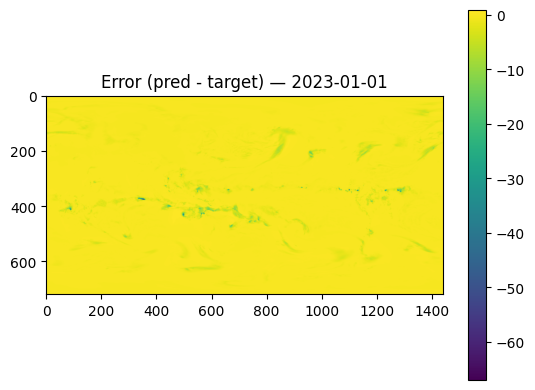

In [10]:
import matplotlib.pyplot as plt

def predict_map(date_str: str):
    model.eval(); head.eval()
    b = build_batch(date_str)
    y = build_target(date_str)  # CPU

    bb_dev = next(model.parameters()).device
    h_dev  = next(head.parameters()).device
    b_dev = move_batch(b, bb_dev)

    with torch.no_grad():
        pred = model(b_dev)
        X = pack_surf_features(pred).to(h_dev)
        yhat = head(X)

    yhat_cpu = yhat.detach().to("cpu").squeeze().numpy()
    y_cpu    = y.detach().to("cpu").squeeze().numpy()

    del b, b_dev, pred, X, yhat, y
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return y_cpu, yhat_cpu


SHOW_DATE = TRAIN_DATES[0]
y_true, y_pred = predict_map(SHOW_DATE)

plt.figure()
plt.title(f"Target (normalized) — {SHOW_DATE}")
plt.imshow(y_true)
plt.colorbar()
plt.show()

plt.figure()
plt.title(f"Prediction (normalized) — {SHOW_DATE}")
plt.imshow(y_pred)
plt.colorbar()
plt.show()

plt.figure()
plt.title(f"Error (pred - target) — {SHOW_DATE}")
plt.imshow(y_pred - y_true)
plt.colorbar()
plt.show()


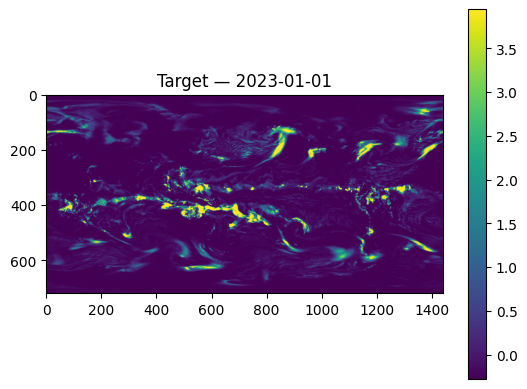

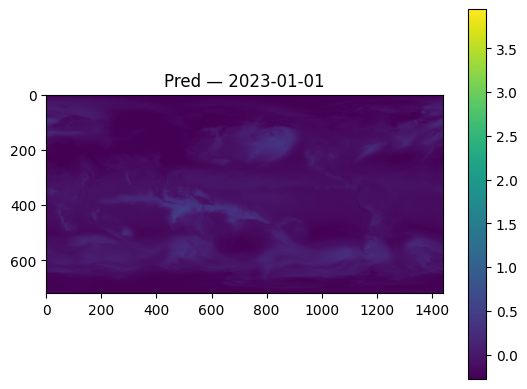

In [11]:
vmin = np.percentile(y_true, 1)
vmax = np.percentile(y_true, 99)

plt.figure(); plt.title(f"Target — {SHOW_DATE}"); plt.imshow(y_true, vmin=vmin, vmax=vmax); plt.colorbar(); plt.show()
plt.figure(); plt.title(f"Pred — {SHOW_DATE}");   plt.imshow(y_pred, vmin=vmin, vmax=vmax); plt.colorbar(); plt.show()


## 9) If GPU OOM happens
Only change in config:
- set `BACKBONE_ON_GPU = False`
- keep `HEAD_ON_GPU = True`

That runs Aurora on CPU and the head on GPU (still much faster than full CPU training).
